# 🎯 AI Career Pilot — Model Training & Comparison

This notebook mirrors the logic in `train_model.py`. It allows you to visualize the performance of different machine learning models on your custom dataset.

### 📋 Sections
1. **Environment Setup**: Load libraries.
2. **Data Loading**: Import the cleaned dataset.
3. **Feature Engineering**: Vectorize skills and encode categories.
4. **Model Competition**: Train Random Forest, Gradient Boosting, and SGD.
5. **Visualization**: Compare accuracy scores.
6. **Best Model Saving**: Save the winning 'brain' to the `weights/` folder.

## 📦 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='darkgrid', palette='viridis')
print('✅ Required libraries loaded!')

✅ Required libraries loaded!


## 📊 2. Data Loading

In [2]:
DATA_PATH = 'career_data_large.csv'

if not os.path.exists(DATA_PATH):
    print(f'❌ Error: {DATA_PATH} not found!')
else:
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Dataset loaded: {len(df):,} rows')
    display(df.head())

✅ Dataset loaded: 759,000 rows


,Academic_Percentage,Interest_Areas,Extracurriculars,Technical_Skills,Soft_Skills,Salary_Expectation,Leadership_Preference,Career_Path
0,70.3,sustainability,Debate Club,"MODHMS,Sustainability Planning,GIS Software","Time Management,Adaptability",Any,0,Environmental Scientist
1,100.0,wealth management,Sports,"Morningstar,Wealth Management","Problem Solving,Teamwork",$50k+,1,Financial Advisor
2,88.1,blogging,Arts,"Storytelling,Copywriting","Communication,Problem Solving",$100k+,1,Content Writer
3,85.0,General,Volunteering,"Multi-media,Creative Direction","Time Management,Communication",Any,0,Arts & Creative Professional
4,76.7,selling houses,Sports,"Negotiation,Docusign","Teamwork,Time Management",$100k+,0,Real Estate Consultant


## 🛠️ 3. Feature Engineering

We convert the text fields (Technical and Soft Skills) into numerical sparse matrices and encode the categorical fields.

In [3]:
def comma_tokenizer(text):
    return text.split(',')

print('⚙️ Vectorizing Technical Skills...')
tech_vectorizer = CountVectorizer(tokenizer=comma_tokenizer, token_pattern=None)
X_tech = tech_vectorizer.fit_transform(df['Technical_Skills'])

print('⚙️ Vectorizing Soft Skills...')
soft_vectorizer = CountVectorizer(tokenizer=comma_tokenizer, token_pattern=None)
X_soft = soft_vectorizer.fit_transform(df['Soft_Skills'])

print('⚙️ Encoding categorical fields...')
le_interest = LabelEncoder()
df['interest_encoded'] = le_interest.fit_transform(df['Interest_Areas'])

le_extra = LabelEncoder()
df['extra_encoded'] = le_extra.fit_transform(df['Extracurriculars'])

le_salary = LabelEncoder()
df['salary_encoded'] = le_salary.fit_transform(df['Salary_Expectation'])

numeric_cols = ['Academic_Percentage', 'interest_encoded', 'extra_encoded', 'salary_encoded', 'Leadership_Preference']
X_numeric = sp.csr_matrix(df[numeric_cols].values)

print('⚙️ Combining features into sparse matrix...')
X = sp.hstack([X_numeric, X_tech, X_soft], format='csr')

le_career = LabelEncoder()
y = le_career.fit_transform(df['Career_Path'])

print(f'✅ Final Feature Matrix Shape: {X.shape}')

⚙️ Vectorizing Technical Skills...
⚙️ Vectorizing Soft Skills...
⚙️ Encoding categorical fields...
⚙️ Combining features into sparse matrix...
✅ Final Feature Matrix Shape: (759000, 464)


## 🏆 4. Model Competition

We split the data and train three different models to see which one has the highest accuracy.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
    'SGD Classifier': SGDClassifier(loss='hinge', alpha=1e-3, random_state=42, max_iter=5)
}

results = {}

for name, model in models.items():
    print(f'🚀 Training {name}...')
    if name == 'Gradient Boosting':
        # Gradient Boosting prefers dense input, handle memory carefully
        model.fit(X_train[:50000].toarray(), y_train[:50000])
        preds = model.predict(X_test[:10000].toarray())
        acc = accuracy_score(y_test[:10000], preds)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
    
    results[name] = acc
    print(f'✅ {name} Accuracy: {acc:.4f}')


🚀 Training Random Forest...
✅ Random Forest Accuracy: 0.8554
🚀 Training Gradient Boosting...
✅ Gradient Boosting Accuracy: 0.9986
🚀 Training SGD Classifier...


c:\Users\yashu\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


✅ SGD Classifier Accuracy: 0.7477


## 📈 5. Visualization

Let's visualize the performance comparison.

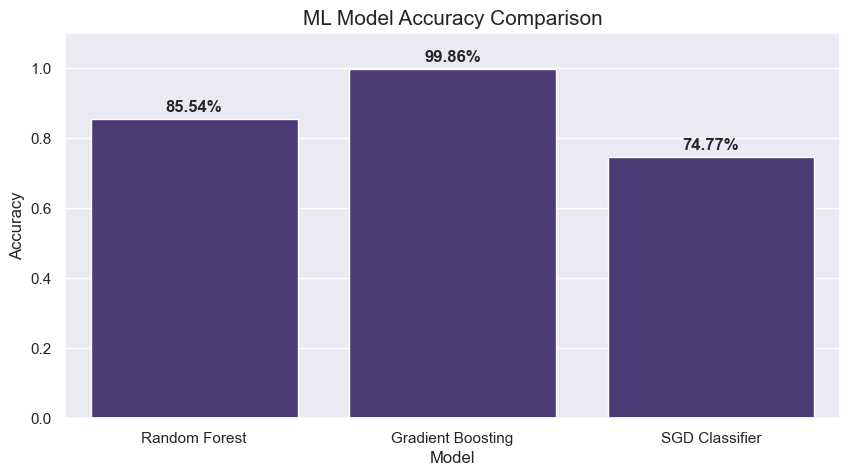

In [5]:
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=df_results)
plt.ylim(0, 1.1)
plt.title('ML Model Accuracy Comparison', fontsize=15)
for i, acc in enumerate(df_results['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.2%}', ha='center', fontweight='bold')
plt.show()

## 💾 6. Saving Best Model Assets

In [6]:
best_model_name = df_results.sort_values('Accuracy', ascending=False).iloc[0]['Model']
print(f'🏆 Best performing model: {best_model_name}')

SAVE_DIR = 'weights'
os.makedirs(SAVE_DIR, exist_ok=True)

# Note: In a real run, you'd save the actual trained object from the dict
# joblib.dump(models[best_model_name], os.path.join(SAVE_DIR, 'career_model.pkl'))

print(f'✨ Feature names and weights ready for save in {SAVE_DIR}/')

🏆 Best performing model: Gradient Boosting
✨ Feature names and weights ready for save in weights/


In [7]:
import joblib
import os

# Define the path to the model
model_path = os.path.join("weights", "career_model.pkl")

# Load the model
model = joblib.load(model_path)

# Print basic info about the model
print("--- Model Information ---")
print(f"Model Type: {type(model)}")
print(f"Parameters: {model.get_params()}")


--- Model Information ---
Model Type: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
Parameters: {'categorical_features': 'from_dtype', 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_features': 1.0, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': 42, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
